# Exploración del modelo
## Aprendizaje Profundo - PCIC
### Eduardo García Alarcón 2025-1

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import speechbrain as sb
import torch as th
import torch.nn as nn
import torchaudio.transforms as T
from tqdm.auto import trange, tqdm
import torchaudio
import pandas as pd
import os
import librosa


SEED = 42
np.random.seed(SEED)
th.manual_seed(SEED)

DEVICE = 'cuda:0' if th.cuda.is_available() else 'cpu'
print(f'{DEVICE = }')

INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [allow_tf32, disable_jit_profiling]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []


DEVICE = 'cuda:0'


classifier.hparams.label_encoder.lab2ind = code_to_indx

## Clases relevantes

### Clases de UrbanSound
- 0 = dog_bark
- 1 = children_playing
- 2 = air_conditioner
- 3 = street_music
- 4 = gun_shot
- 5 = siren
- 6 = engine_idling
- 7 = jackhammer
- 8 = drilling
- 9 = car_horn

In [2]:
lable_to_code = {
  'Bark': '/m/05tny_', 
  'Children playing': '/t/dd00013',
  'Air conditioning': '/m/025wky1',
  # 'Music',
  'Gunshot, gunfire': '/m/032s66',
  'Police car (siren)': '/m/04qvtq', 'Ambulance (siren)': '/m/012n7d',
  'Engine': '/m/02mk9',
  'Jackhammer': '/m/03p19w',
  'Drill': '/m/01d380',
  'Vehicle horn, car horn, honking': '/m/0912c9',
}

In [3]:
code_to_lable  = {item: key for key, item in lable_to_code.items()}

In [4]:
code_to_lable

{'/m/05tny_': 'Bark',
 '/t/dd00013': 'Children playing',
 '/m/025wky1': 'Air conditioning',
 '/m/032s66': 'Gunshot, gunfire',
 '/m/04qvtq': 'Police car (siren)',
 '/m/012n7d': 'Ambulance (siren)',
 '/m/02mk9': 'Engine',
 '/m/03p19w': 'Jackhammer',
 '/m/01d380': 'Drill',
 '/m/0912c9': 'Vehicle horn, car horn, honking'}

In [5]:
code_to_indx = {key: i for i, key in enumerate(code_to_lable.keys())}

In [6]:
indx_to_lable = {}
for code, indx in code_to_indx.items():
    indx_to_lable[indx] = code_to_lable[code]

In [7]:
indx_to_lable

{0: 'Bark',
 1: 'Children playing',
 2: 'Air conditioning',
 3: 'Gunshot, gunfire',
 4: 'Police car (siren)',
 5: 'Ambulance (siren)',
 6: 'Engine',
 7: 'Jackhammer',
 8: 'Drill',
 9: 'Vehicle horn, car horn, honking'}

In [8]:
code_to_indx.items()

dict_items([('/m/05tny_', 0), ('/t/dd00013', 1), ('/m/025wky1', 2), ('/m/032s66', 3), ('/m/04qvtq', 4), ('/m/012n7d', 5), ('/m/02mk9', 6), ('/m/03p19w', 7), ('/m/01d380', 8), ('/m/0912c9', 9)])

In [9]:
code_to_indx

{'/m/05tny_': 0,
 '/t/dd00013': 1,
 '/m/025wky1': 2,
 '/m/032s66': 3,
 '/m/04qvtq': 4,
 '/m/012n7d': 5,
 '/m/02mk9': 6,
 '/m/03p19w': 7,
 '/m/01d380': 8,
 '/m/0912c9': 9}

In [10]:
codes = [key for key in code_to_lable.keys()]

In [11]:
codes

['/m/05tny_',
 '/t/dd00013',
 '/m/025wky1',
 '/m/032s66',
 '/m/04qvtq',
 '/m/012n7d',
 '/m/02mk9',
 '/m/03p19w',
 '/m/01d380',
 '/m/0912c9']

## Dataframes

### Abrimos los CSV

In [12]:
df_val = pd.read_csv(
  'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/eval_segments.csv',
	delimiter=', ',
	header=2)
    
df_train = pd.read_csv(
  'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/balanced_train_segments.csv',
  delimiter=', ',
	header=2)
    
df_train_unbalanced = pd.read_csv(
  'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/unbalanced_train_segments.csv',
  delimiter=', ',
	header=2)

/tmp/ipykernel_1063145/1454075283.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_val = pd.read_csv(
/tmp/ipykernel_1063145/1454075283.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_train = pd.read_csv(
/tmp/ipykernel_1063145/1454075283.py:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_train_unbalanced = pd.read_csv(


In [13]:
df_train.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,--PJHxphWEs,30.0,40.0,"""/m/09x0r,/t/dd00088"""
1,--ZhevVpy1s,50.0,60.0,"""/m/012xff"""
2,--aE2O5G5WE,0.0,10.0,"""/m/03fwl,/m/04rlf,/m/09x0r"""
3,--aO5cdqSAg,30.0,40.0,"""/t/dd00003,/t/dd00005"""
4,--aaILOrkII,200.0,210.0,"""/m/032s66,/m/073cg4"""


In [14]:
df_train_unbalanced.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,---1_cCGK4M,0.0,10.0,"""/m/01g50p,/m/0284vy3,/m/06d_3,/m/07jdr,/m/07r..."
1,---2_BBVHAA,30.0,40.0,"""/m/09x0r"""
2,---B_v8ZoBY,30.0,40.0,"""/m/04rlf"""
3,---EDNidJUA,30.0,40.0,"""/m/02qldy,/m/02zsn,/m/05zppz,/m/09x0r"""
4,---N4cFAE1A,21.0,31.0,"""/m/04rlf,/m/09x0r"""


In [15]:
df_val.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,--4gqARaEJE,0.0,10.0,"""/m/068hy,/m/07q6cd_,/m/0bt9lr,/m/0jbk"""
1,--BfvyPmVMo,20.0,30.0,"""/m/03l9g"""
2,--U7joUcTCo,0.0,10.0,"""/m/01b_21"""
3,--i-y1v8Hy8,0.0,9.0,"""/m/04rlf,/m/09x0r,/t/dd00004,/t/dd00005"""
4,-0BIyqJj9ZU,30.0,40.0,"""/m/07rgt08,/m/07sq110,/t/dd00001"""


## Descargamos los datos

In [16]:
from Util import audioSet_download, file_mover, actual_df

In [22]:
audioSet_download(lable_to_code, dataset='balanced_train', out_dir='./Data2/')

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


[youtube] Extracting URL: https://www.youtube.com/watch?v=--aaILOrkII
[youtube] --aaILOrkII: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-2PDE7hUArE
[youtube] -2PDE7hUArE: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-4RWqM0UCCY
[youtube] -4RWqM0UCCY: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-75IwDlkzDQ
[youtube] -75IwDlkzDQ: Downloading webpage
[youtube] --aaILOrkII: Downloading ios player API JSON
[youtube] -4RWqM0UCCY: Downloading ios player API JSON
[youtube] -2PDE7hUArE: Downloading ios player API JSON
[youtube] -75IwDlkzDQ: Downloading ios player API JSON
[youtube] --aaILOrkII: Downloading mweb player API JSON
[youtube] -2PDE7hUArE: Downloading mweb player API JSON
[youtube] -4RWqM0UCCY: Downloading mweb player API JSON
[youtube] -75IwDlkzDQ: Downloading mweb player API JSON
[youtube] -4RWqM0UCCY: Downloading m3u8 information
[youtube] -75IwDlkzDQ: Downloading m3u8 information


Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


[download] 100% of    3.38MiB in 00:00:00 at 8.79MiB/s   
Deleting original file ./Data2/AudioSet/Engine/-2PDE7hUArE_30.0-40.0.m4a (pass -k to keep)
[FixupM4a] Correcting container of "./Data2/AudioSet/Gunshot, gunfire/--aaILOrkII_200.0-210.0.m4a"
[ExtractAudio] Destination: ./Data2/AudioSet/Gunshot, gunfire/--aaILOrkII_200.0-210.0.ogg


Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


...

Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


[youtube] Extracting URL: https://www.youtube.com/watch?v=zu53y8M2xBc
[youtube] zu53y8M2xBc: Downloading webpage
[youtube] zHy43cBfK9M: Downloading m3u8 information
[youtube] znWyOGuH4EY: Downloading ios player API JSON
[youtube] zj0wawtfZsA: Downloading m3u8 information
[youtube] zu53y8M2xBc: Downloading ios player API JSON
[youtube] znWyOGuH4EY: Downloading mweb player API JSON
[youtube] zu53y8M2xBc: Downloading mweb player API JSON
[info] zj0wawtfZsA: Downloading 1 format(s): 251
[info] zHy43cBfK9M: Downloading 1 format(s): 140
[download] Destination: ./Data2/AudioSet/Gunshot, gunfire/zHy43cBfK9M_30.0-40.0.m4a
[download]   0.6% of    4.89MiB at    3.74MiB/s ETA 00:01[download] Destination: ./Data2/AudioSet/Speech/zj0wawtfZsA_10.0-20.0.webm
[download] 100% of    4.89MiB in 00:00:00 at 13.66MiB/s  
[download] 100% of    2.80MiB in 00:00:00 at 7.45MiB/s   
[FixupM4a] Correcting container of "./Data2/AudioSet/Gunshot, gunfire/zHy43cBfK9M_30.0-40.0.m4a"
[ExtractAudio] Destination: ./Data

Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


[youtube] Extracting URL: https://www.youtube.com/watch?v=zz8TGV83nkE
[youtube] zz8TGV83nkE: Downloading webpage
[youtube] znWyOGuH4EY: Downloading m3u8 information
[ExtractAudio] Destination: ./Data2/AudioSet/Gunshot, gunfire/zu53y8M2xBc_20.0-30.0.ogg
Deleting original file ./Data2/AudioSet/Gunshot, gunfire/zu53y8M2xBc_20.0-30.0.m4a (pass -k to keep)
[info] znWyOGuH4EY: Downloading 1 format(s): 140
[download] Destination: ./Data2/AudioSet/Drill/znWyOGuH4EY_230.0-240.0.m4a
[download]   5.7% of    8.75MiB at    4.29MiB/s ETA 00:01[youtube] zz8TGV83nkE: Downloading ios player API JSON
[download]  45.7% of    8.75MiB at   18.88MiB/s ETA 00:00[youtube] zz8TGV83nkE: Downloading mweb player API JSON
[download] 100% of    8.75MiB in 00:00:00 at 19.13MiB/s  
[FixupM4a] Correcting container of "./Data2/AudioSet/Drill/znWyOGuH4EY_230.0-240.0.m4a"
[ExtractAudio] Destination: ./Data2/AudioSet/Drill/znWyOGuH4EY_230.0-240.0.ogg
Deleting original file ./Data2/AudioSet/Drill/znWyOGuH4EY_230.0-240.0.m4

[Parallel(n_jobs=4)]: Done 818 out of 818 | elapsed:  9.7min finished


In [ ]:
archivos_disponibles = file_mover(check_dir='./Data2/AudioSet/', new_dir='./Data2/Audios/')
print(f'{len(archivos_disponibles) = }')
df = actual_df(df_train.copy(), archivos_disponibles)

Todos los audios han sido movidos


In [63]:
audioSet_download(lable_to_code, dataset='eval', out_dir='./Data3/')

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


[youtube] Extracting URL: https://www.youtube.com/watch?v=-1pRmoJIGQc
[youtube] -1pRmoJIGQc: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-3-JjN3BXjA
[youtube] -3-JjN3BXjA: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-3YWuPXHknk
[youtube] -3YWuPXHknk: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-9GUUhB3QV0
[youtube] -9GUUhB3QV0: Downloading webpage
[youtube] -3-JjN3BXjA: Downloading ios player API JSON
[youtube] -9GUUhB3QV0: Downloading ios player API JSON
[youtube] -3YWuPXHknk: Downloading ios player API JSON
[youtube] -3-JjN3BXjA: Downloading mweb player API JSON
[youtube] -3YWuPXHknk: Downloading mweb player API JSON
[youtube] -9GUUhB3QV0: Downloading mweb player API JSON


ERROR: [youtube] -3YWuPXHknk: Video unavailable
ERROR: [youtube] -3-JjN3BXjA: Private video. Sign in if you've been granted access to this video
ERROR: [youtube] -9GUUhB3QV0: Video unavailable. This video is no longer available because the YouTube account associated with this video has been terminated.


[youtube] -1pRmoJIGQc: Downloading ios player API JSON
[youtube] -1pRmoJIGQc: Downloading mweb player API JSON


Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


...

Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above


[youtube] Extracting URL: https://www.youtube.com/watch?v=ztfXxgXqHGM
[youtube] ztfXxgXqHGM: Downloading webpage
[download]  71.1% of   16.70MiB at   50.72MiB/s ETA 00:00  [youtube] ztfXxgXqHGM: Downloading ios player API JSON
[download]  83.1% of   16.70MiB at   16.68MiB/s ETA 00:00[youtube] ztfXxgXqHGM: Downloading mweb player API JSON
[download] 100.0% of   16.70MiB at   17.91MiB/s ETA 00:00

ERROR: [youtube] ztfXxgXqHGM: Sign in to confirm your age. This video may be inappropriate for some users.


[youtube] zj_Ia5cJE4s: Downloading m3u8 information
[download] 100% of   16.70MiB in 00:00:01 at 9.60MiB/s   
[ExtractAudio] Destination: ./Data3/AudioSet/Music/zhrRL8yzTEs_190.0-200.0.ogg
[info] zj_Ia5cJE4s: Downloading 1 format(s): 140
[download] Destination: ./Data3/AudioSet/Drill/zj_Ia5cJE4s_100.0-110.0.m4a
[download]  44.8% of    4.46MiB at    9.50MiB/s ETA 00:00Deleting original file ./Data3/AudioSet/Music/zhrRL8yzTEs_190.0-200.0.webm (pass -k to keep)
[download] 100% of    4.46MiB in 00:00:00 at 5.63MiB/s   
[FixupM4a] Correcting container of "./Data3/AudioSet/Drill/zj_Ia5cJE4s_100.0-110.0.m4a"
[ExtractAudio] Destination: ./Data3/AudioSet/Drill/zj_Ia5cJE4s_100.0-110.0.ogg
Deleting original file ./Data3/AudioSet/Drill/zj_Ia5cJE4s_100.0-110.0.m4a (pass -k to keep)
Done.
Descarga completada!!!
Tiempo transcurrido 649.6315586566925


[Parallel(n_jobs=4)]: Done 816 out of 816 | elapsed: 10.8min finished


In [64]:
archivos_disponibles = file_mover(check_dir='./Data3/AudioSet/', new_dir='./Data3/Audios/')
print(f'{len(archivos_disponibles) = }')
# df = actual_df(df_train.copy(), archivos_disponibles)

Todos los audios han sido movidos
len(archivos_disponibles) = 675


In [25]:

df = actual_df(df_train.copy(), archivos_disponibles)


## Usaremos solo las 10 clases relevantes
Y haremos el split de los datos para con 80% entrenamiento y 20% entrenamiento 

In [ ]:
df

,# YTID,start_seconds,end_seconds,positive_labels
62,--330hg-Ocw,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00066,/t/dd00130"""
154,--8puiAGLhs,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00130"""
226,--Dxk606LRQ,30.0,40.0,"""/m/02mk9"""
233,--EG-JqO4S0,30.0,40.0,"""/m/02mk9,/m/07pb8fc,/m/07q2z82,/m/09x0r,/t/dd..."
291,--HXYSM3ydo,2.0,12.0,"""/m/0912c9,/m/09x0r"""
...,...,...,...,...
1158284,Su99pnKMZqo,0.0,7.0,"""/m/0912c9"""
1158311,SuCaHPRqFRA,30.0,40.0,"""/m/02mk9,/m/07yv9"""
1158506,SueelTSNh4s,110.0,120.0,"""/m/02mk9,/m/04rlf,/m/07yv9,/m/09x0r"""
1158666,Sv1ztR7CG8M,100.0,110.0,"""/m/019jd,/m/02mk9,/m/07yv9"""


#### Creamos una columna para las categorías

In [26]:
df['indx'] = df['positive_labels'].apply(lambda x: next((code_to_indx.get(code) for code in codes if code in x), None) if pd.notnull(x) else None)

In [27]:
df_train['indx'] = df_train['positive_labels'].apply(lambda x: next((code_to_indx.get(code) for code in codes if code in x), None) if pd.notnull(x) else None)

In [28]:
df_train_unbalanced['indx'] = df_train_unbalanced['positive_labels'].apply(lambda x: next((code_to_indx.get(code) for code in codes if code in x), None) if pd.notnull(x) else None)

In [29]:
df_val['indx'] = df_val['positive_labels'].apply(lambda x: next((code_to_indx.get(code) for code in codes if code in x), None) if pd.notnull(x) else None)

In [ ]:
df

,# YTID,start_seconds,end_seconds,positive_labels,indx
62,--330hg-Ocw,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00066,/t/dd00130""",6
154,--8puiAGLhs,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00130""",6
226,--Dxk606LRQ,30.0,40.0,"""/m/02mk9""",6
233,--EG-JqO4S0,30.0,40.0,"""/m/02mk9,/m/07pb8fc,/m/07q2z82,/m/09x0r,/t/dd...",6
291,--HXYSM3ydo,2.0,12.0,"""/m/0912c9,/m/09x0r""",9
...,...,...,...,...,...
1158284,Su99pnKMZqo,0.0,7.0,"""/m/0912c9""",9
1158311,SuCaHPRqFRA,30.0,40.0,"""/m/02mk9,/m/07yv9""",6
1158506,SueelTSNh4s,110.0,120.0,"""/m/02mk9,/m/04rlf,/m/07yv9,/m/09x0r""",6
1158666,Sv1ztR7CG8M,100.0,110.0,"""/m/019jd,/m/02mk9,/m/07yv9""",6


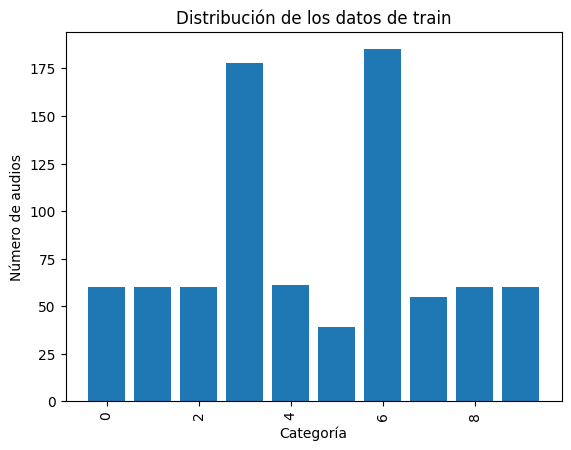

In [ ]:
idx, cuentas = np.unique(df_train.indx, return_counts=True)
plt.bar(x=idx, height=cuentas)
plt.title('Distribución de los datos de train')
# plt.xticks(rotation=90)
plt.xlabel('Categoría')
plt.ylabel('Número de audios')
plt.show()

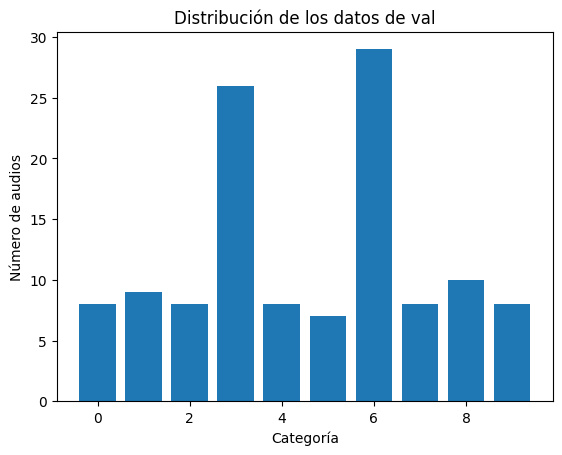

In [65]:
idx, cuentas = np.unique(df_val.indx, return_counts=True)
plt.bar(x=idx, height=cuentas)
# plt.xticks(rotation=90)
plt.title('Distribución de los datos de val')
plt.xlabel('Categoría')
plt.ylabel('Número de audios')
plt.show()

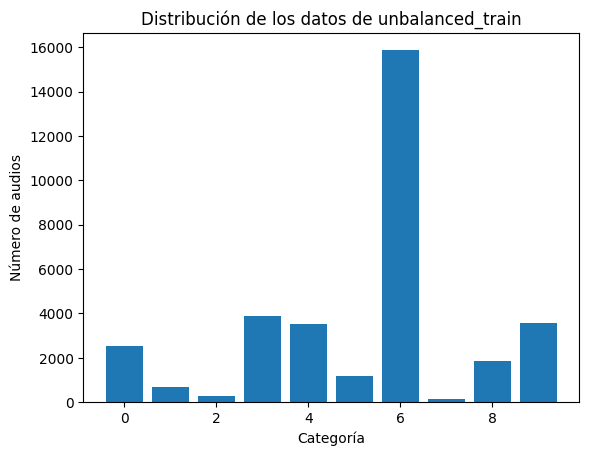

In [41]:
idx, cuentas = np.unique(df_train_unbalanced.indx, return_counts=True)
plt.bar(x=idx, height=cuentas)
# plt.xticks(rotation=90)
plt.title('Distribución de los datos de unbalanced_train')
plt.xlabel('Categoría')
plt.ylabel('Número de audios')
plt.show()

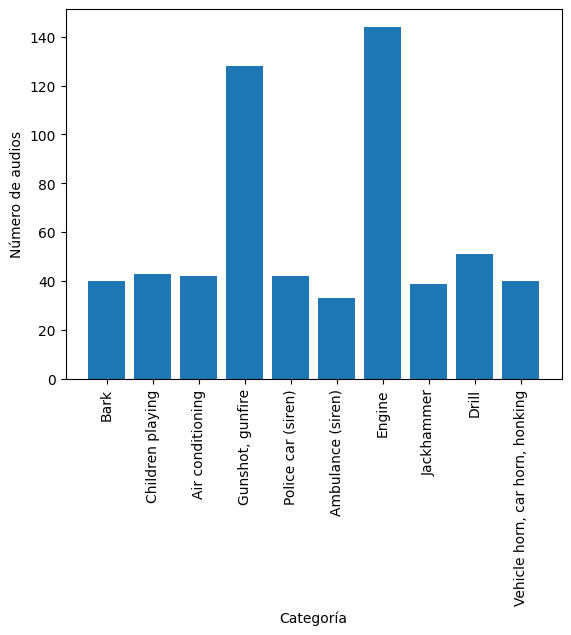

In [30]:
idx, cuentas = np.unique(df.indx, return_counts=True)
plt.bar(x=[indx_to_lable[indx] for indx in idx], height=cuentas)
plt.xticks(rotation=90)
plt.xlabel('Categoría')
plt.ylabel('Número de audios')
plt.show()

### Hacemos el split de datos

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
df_train, df_val = train_test_split(df, test_size=.2, random_state=SEED, shuffle=True, stratify=df.indx)

In [44]:
df_train.shape

(481, 5)

In [45]:
df_val.shape

(121, 5)

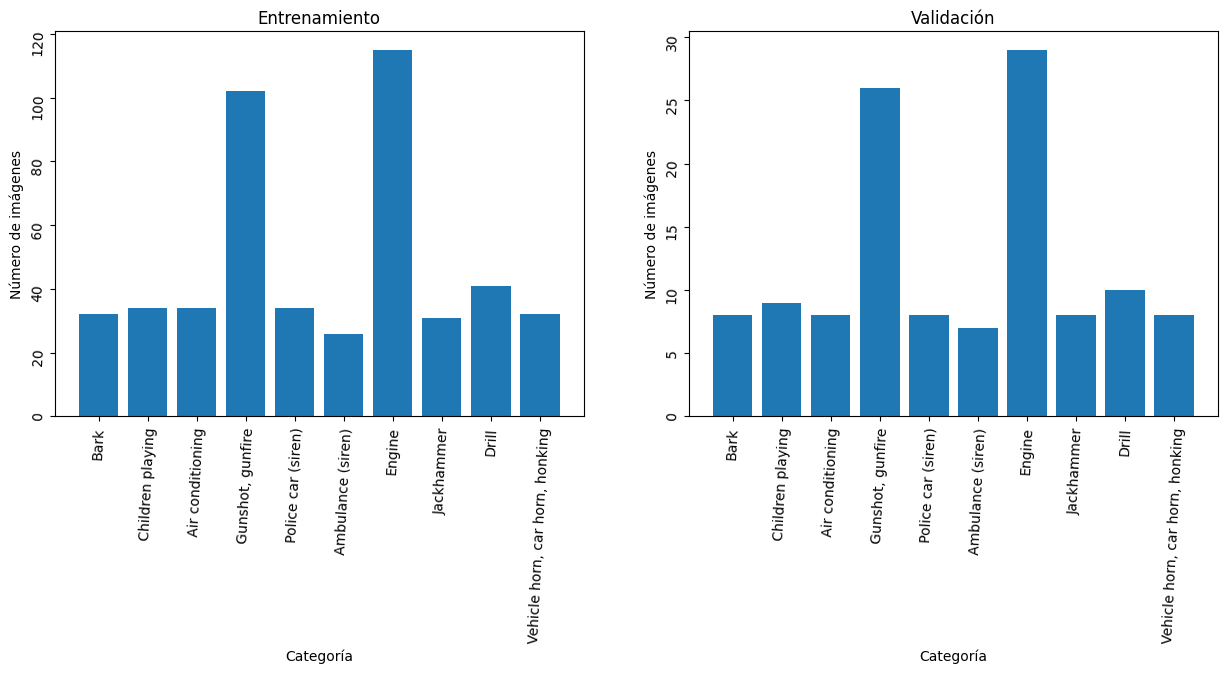

In [46]:
idx_ent, cuentas_ent = np.unique(df_train.indx, return_counts=True)
idx_val, cuentas_val = np.unique(df_val.indx, return_counts=True)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

axs[0].bar(x=[indx_to_lable[indx] for indx in idx_ent], height=cuentas_ent)
axs[0].set_title('Entrenamiento')
axs[0].set_xlabel('Categoría')
axs[0].set_ylabel('Número de imágenes')
axs[0].tick_params(rotation=87)

axs[1].bar(x=[indx_to_lable[indx] for indx in idx_val], height=cuentas_val)
axs[1].set_title('Validación')
axs[1].set_xlabel('Categoría')
axs[1].set_ylabel('Número de imágenes')
axs[1].tick_params(rotation=87)

plt.show()

### Data Augmentation

In [47]:
class AudioPadding(nn.Module):
  def __init__(self):
    super().__init__()
    self.expected_size = 10 * 16000 # tiempo * sample rate
    
  def forward(self, waveform):
    if type(waveform) is tuple:
      waveform = waveform[0]
    # print(f'Padding {waveform.shape = }')
    if waveform.shape[1] < self.expected_size:
      padding_len = self.expected_size - waveform.shape[1]
      padding = th.zeros(1, padding_len)
      # print(f'{padding.shape = }')
      waveform = th.cat([waveform, padding], 1)

    elif waveform.shape[1] > self.expected_size:
      start = np.random.randint(0, waveform.shape[1] - self.expected_size)
      waveform = waveform.narrow(1, start, self.expected_size)

      
    return waveform

In [48]:
class RandomSilence(nn.Module):
  def __init__(self, ratio=.3):
    super().__init__()
    self.ratio = ratio

  def forward(self, waveform):
    samples = waveform.shape[0]
    # print(samples)
    silence_size = int(samples * self.ratio)
    # print(f'{silence_size = }')
    start = np.random.randint(0, samples - silence_size)
    # print(f'{start = }')
    waveform[start:start+silence_size, :] = 0.0
    # if waveform.shape
    return waveform

In [49]:
class SizeChecker(nn.Module):
  def __init__(self):
    super(SizeChecker, self).__init__()

  def forward(self, mfcc):
    if mfcc.size(2) > 800:
      mfcc = mfcc[:, :, :800]
    return mfcc
    

In [50]:
tr_train = nn.Sequential(
  AudioPadding(),
  T.SpeedPerturbation(16000, [0.85, 1.0, 1.0, 1.0, 1.1]),
  AudioPadding(),
  RandomSilence(),
  T.MFCC(sample_rate=16000, n_mfcc=80, melkwargs={'n_fft': 400, "hop_length":160}),
  SizeChecker()
)

tr_val = nn.Sequential(
  AudioPadding(),
  # RandomSilence(),
  T.MFCC(sample_rate=16000, n_mfcc=80, melkwargs={'n_fft': 400, "hop_length":160}),
  SizeChecker()
)


/home/ar/.local/lib/python3.8/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


### Dataset y  DataLoader

In [51]:
from torch.utils.data import Dataset, DataLoader

In [52]:
class AudioLoader(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.root = './Data/Audios/'

        
    def __getitem__(self, idx):
        cat = self.df.indx.iloc[idx] # Categoría
        # Columna
        tmp_row = self.df.iloc[idx]
        # Generamos el nombre del archivo
        name = f"{tmp_row.iloc[0]}_{tmp_row.iloc[1]}-{tmp_row.iloc[2]}."
        # print(f'{name=}')/
        # Buscamos la extensión
        for filename in os.listdir(self.root):
            if filename.startswith(name):
                name = filename
                # print(f'{filename = }')
                
        # Abrimos el audio
        audio, sr = librosa.load(os.path.join(self.root, name), sr=16000)
        # print(f'{len(audio) = }')
        audio = th.tensor(audio[np.newaxis, :])
        # print(f'{name = }')
        # print(f'Loader {audio.shape = }')
        if self.transform:
            audio = self.transform(audio)
            
        # Test para pasar solo el path al archivo
        # audio = os.path.join(self.root, name)
        return audio, th.tensor(cat, dtype=th.long)


    def __len__(self):
        return len(self.df) 

In [53]:
ds_train = AudioLoader(df_train, transform=tr_train)
ds_val   = AudioLoader(df_val, transform=tr_val)

In [54]:
it_train = iter(ds_train)

In [55]:
next(it_train)

(tensor([[[-1.1314e+03, -1.1314e+03, -1.1314e+03,  ..., -1.1314e+03,
           -1.1314e+03, -1.1314e+03],
          [ 9.6589e-05,  9.6589e-05,  9.6589e-05,  ...,  9.6589e-05,
            9.6589e-05,  9.6589e-05],
          [-6.9946e-05, -6.9946e-05, -6.9946e-05,  ..., -6.9946e-05,
           -6.9946e-05, -6.9946e-05],
          ...,
          [ 1.2112e-04,  1.2112e-04,  1.2112e-04,  ...,  1.2112e-04,
            1.2112e-04,  1.2112e-04],
          [-1.2675e-04, -1.2675e-04, -1.2675e-04,  ..., -1.2675e-04,
           -1.2675e-04, -1.2675e-04],
          [ 4.3297e-04,  4.3297e-04,  4.3297e-04,  ...,  4.3297e-04,
            4.3297e-04,  4.3297e-04]]]),
 tensor(7))

In [56]:
dl_train = DataLoader(ds_train, batch_size=64, shuffle=True)
dl_val   = DataLoader(ds_val, batch_size=64)

In [57]:
# desplegamos un lote de ejemplos
x, labels = next(iter(dl_train))
print(f'x shape={x.shape} dtype={type(x)}')
# print(f'y shape={y.shape} dtype={y.dtype}')
print(f'{labels = }')

x shape=torch.Size([64, 1, 80, 800]) dtype=<class 'torch.Tensor'>
labels = tensor([0, 8, 4, 2, 8, 8, 6, 1, 3, 7, 6, 7, 9, 3, 6, 3, 8, 3, 6, 3, 1, 9, 3, 6,
        6, 3, 9, 4, 2, 4, 3, 3, 6, 3, 6, 9, 4, 1, 4, 7, 4, 3, 2, 3, 4, 6, 6, 3,
        4, 4, 3, 6, 3, 6, 6, 2, 6, 4, 8, 0, 6, 3, 7, 8])


## Transfer Learning

In [41]:
from speechbrain.inference.classifiers import EncoderClassifier
classifier = EncoderClassifier.from_hparams(source="speechbrain/urbansound8k_ecapa", savedir="pretrained_models/gurbansound8k_ecapa", run_opts={"device":"cuda"})

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached


INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
/home/ar/.local/lib/python3.8/site-packages/speechbrain/utils/autocast.py:68: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, classifier, label_encoder
/home/ar/.local/lib/python3.8/site-packages/speechbrain/utils/check

### Funciones

In [50]:
from torch.utils.tensorboard import SummaryWriter

def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)

def guarda_ckpt(ckptpath, modelo, epoca, opt):
  estado_modelo = {'epoch': epoca,
                   'model_state_dict': modelo.state_dict(),
                   'optimizer_state_dict': opt.state_dict()}
  th.save(estado_modelo, ckptpath)

def exactitud(y_hat, y):
  cmp = y_hat.argmax(dim=-1) == y
  aciertos = th.count_nonzero(cmp)
  return aciertos / cmp.shape[0]

def paso_ent(modelo,
             fp,
             metrica,
             opt,
             X,
             y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                    # a actualizaren en cero
  out_prob, score, y_hat, tex_lab = modelo.classify_batch(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat, y) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo

  with th.no_grad():
    perdida_paso = perdida.cpu().numpy() # convertimos la pérdida (instancia de
                                         # Tensor de orden 0) a NumPy, para
                                         # lo que es necesario moverla a CPU
    metricas_paso = metrica(y_hat, y)

  return perdida_paso, metricas_paso

### Número de clases

In [58]:
no_clases = df['indx'].unique().shape[0]
print(f'Numero de clases: {no_clases}')

Numero de clases: 10


### Capa lineal para la nueva clasificación
Y ponemos los parámetros con ```requires_grad = False``` para no entrenar la red desde cero

In [48]:
for name, p in classifier.named_parameters():
  if not name.startswith('classifier'):
    p.requires_grad = False

# Ponemos el modelo en modol evaluación
classifier.eval()

EncoderClassifier(
  (mods): ModuleDict(
    (compute_features): Fbank(
      (compute_STFT): STFT()
      (compute_fbanks): Filterbank()
      (compute_deltas): Deltas()
      (context_window): ContextWindow()
    )
    (mean_var_norm): InputNormalization()
    (embedding_model): ECAPA_TDNN(
      (blocks): ModuleList(
        (0): TDNNBlock(
          (conv): Conv1d(
            (conv): Conv1d(80, 1024, kernel_size=(5,), stride=(1,))
          )
          (activation): ReLU()
          (norm): BatchNorm1d(
            (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): SERes2NetBlock(
          (tdnn1): TDNNBlock(
            (conv): Conv1d(
              (conv): Conv1d(1024, 1024, kernel_size=(1,), stride=(1,))
            )
            (activation): ReLU()
            (norm): BatchNorm1d(
              (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
     

### Agregamos la capa fully connected

In [ ]:
num_params = sum([p.numel() for p in classifier.parameters()])
trainable_params = sum([p.numel() for p in classifier.parameters() if p.requires_grad])

print(f"{num_params = :,} | {trainable_params = :,}")

In [51]:
import copy

def entrena(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {'perdida_ent':np.zeros(n_epocas),
          'perdida_val': np.zeros(n_epocas),
          metrica.__name__ + '_ent': np.zeros(n_epocas),
          metrica.__name__ + '_val': np.zeros(n_epocas)}

  tbwriter = SummaryWriter(tbdir)
  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in trange(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for p, (Xlote,ylote) in enumerate(entdl):
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist['perdida_ent'][e] += perdida_paso
      hist[metrica.__name__ + '_ent'][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['perdida_val'][e] += fp(y_hat, ylote)
        hist[metrica.__name__ + '_val'][e] += metrica(y_hat, ylote)

    hist['perdida_ent'][e] /=  n_lotes_ent
    hist[metrica.__name__ + '_ent'][e] /= n_lotes_ent
    hist['perdida_val'][e] /=  n_lotes_val
    hist[metrica.__name__ + '_val'][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['perdida_val'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['perdida_val'][e]

    registra_info_tboard(tbwriter, e, hist)

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["perdida_ent"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist[metrica.__name__ + "_ent"][e]:.3f}, '
          f'Perdida(V) = {hist["perdida_val"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist[metrica.__name__ + "_val"][e]:.3f}')

  return modelo, mejor_modelo, hist

In [52]:
from torch.optim import Adam

In [53]:
LOGDIR = './logs/'

perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean',
                              label_smoothing=0.1)
opt = Adam(classifier.parameters(),
           lr=0.001)

classifier, mejor_classifier, hist = entrena(classifier,
                                     perdida,
                                     exactitud,
                                     opt,
                                     dl_train,
                                     dl_val,
                                     DEVICE,
                                     LOGDIR + 'classifier.pt',
                                     n_epocas=10,
                                     tbdir = LOGDIR)

  0%|          | 0/10 [00:00<?, ?it/s]

NotImplementedError: Only 2D, 3D, 4D, 5D padding with non-constant padding are supported for now

### Usamos otro modelo ya que el actual no funciona, entonces para por lo menos poder tener algún resultado

In [59]:
import copy

def entrena_1d(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {'perdida_ent':np.zeros(n_epocas),
          'perdida_val': np.zeros(n_epocas),
          metrica.__name__ + '_ent': np.zeros(n_epocas),
          metrica.__name__ + '_val': np.zeros(n_epocas)}

  tbwriter = SummaryWriter(tbdir)
  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in trange(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for p, (Xlote,ylote) in enumerate(entdl):
      
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)
      #Formateamos las dimensiones de Xlote
      Xlote = Xlote.reshape(Xlote.size(0), 1, -1)  
        
      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist['perdida_ent'][e] += perdida_paso
      hist[metrica.__name__ + '_ent'][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp).long()
          
        # Cambio de foramto
        Xlote = Xlote.reshape(Xlote.size(0), 1, -1)    
        y_hat = modelo(Xlote)

        hist['perdida_val'][e] += fp(y_hat, ylote)
        hist[metrica.__name__ + '_val'][e] += metrica(y_hat, ylote)

    hist['perdida_ent'][e] /=  n_lotes_ent
    hist[metrica.__name__ + '_ent'][e] /= n_lotes_ent
    hist['perdida_val'][e] /=  n_lotes_val
    hist[metrica.__name__ + '_val'][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['perdida_val'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['perdida_val'][e]

    registra_info_tboard(tbwriter, e, hist)

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["perdida_ent"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist[metrica.__name__ + "_ent"][e]:.3f}, '
          f'Perdida(V) = {hist["perdida_val"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist[metrica.__name__ + "_val"][e]:.3f}')

  return modelo, mejor_modelo, hist
######
from torch.utils.tensorboard import SummaryWriter
import torch as th

def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)

def guarda_ckpt(ckptpath, modelo, epoca, opt):
  estado_modelo = {'epoch': epoca,
                   'model_state_dict': modelo.state_dict(),
                   'optimizer_state_dict': opt.state_dict()}
  th.save(estado_modelo, ckptpath)
######
def exactitud(y_hat, y):
  cmp = y_hat.argmax(dim=-1) == y
  aciertos = th.count_nonzero(cmp)
  return aciertos / cmp.shape[0]

######
def paso_ent(modelo,
             fp,
             metrica,
             opt,
             X,
             y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                    # a actualizaren en cero
  y_hat = modelo(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat, y) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo

  with th.no_grad():
    perdida_paso = perdida.cpu().numpy() # convertimos la pérdida (instancia de
                                         # Tensor de orden 0) a NumPy, para
                                         # lo que es necesario moverla a CPU
    metricas_paso = metrica(y_hat, y)

  return perdida_paso, metricas_paso



In [60]:
class Red1D(nn.Module):
  def __init__(self,  input_size, num_clases, sr=16000):
    super(Red1D, self).__init__()
    self.input_size = input_size
    self.num_clases = num_clases
    self.sr = sr
    # self.name = 'Red1D'
    
    self.conv1 = nn.Conv1d(input_size, 20, 3)
    self.maxPool = nn.MaxPool1d(4)
    self.conv2 = nn.Conv1d(20, 4, 3)
    self.globAvgPool = nn.MaxPool1d(1)
    self.fc = nn.Linear(4*3999, num_clases)

  def forward(self, x):
    # print(f'{x.shape=}')
    # x = self.data_aug(x)
    x = self.conv1(x)
    # print(f'conv1 {x.shape=}')
    x = self.maxPool(x)
    # print(f'maxPool {x.shape=}')
    x = self.conv2(x)
    # print(f'conv2 {x.shape=}')
    x = self.maxPool(x)
    # print(f'maxPool{x.shape=}')
    x = self.globAvgPool(x)
    # print(f'globalAvg{x.shape=}')
    x = nn.functional.relu(x)
    # print(f'relu {x.shape=}')
    x = x.view(-1,4*3999)
    # print(f'view {x.shape=}')
    x = self.fc(x)
    return x


In [62]:
# Entrenamos
modelo = Red1D(input_size=1, num_clases=10, sr=16000)
modelo.to(DEVICE)

LOGDIR = './logs/'

perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean')

opt = th.optim.Adam(modelo.parameters(),
                    lr=0.001)

modelo, mejor_modelo, hist = entrena_1d(modelo,
                                     perdida,
                                     exactitud,
                                     opt,
                                     dl_train,
                                     dl_val,
                                     DEVICE,
                                     LOGDIR+'red1_data2.pt',
                                     n_epocas=25,
                                     tbdir=LOGDIR)

  0%|          | 0/25 [00:00<?, ?it/s]


Época 0: Perdida(E) = 31.938, exactitud(E) = 0.115, Perdida(V) = 17.904, exactitud(V) = 0.114

Época 1: Perdida(E) = 6.845, exactitud(E) = 0.167, Perdida(V) = 3.986, exactitud(V) = 0.241

Época 2: Perdida(E) = 3.791, exactitud(E) = 0.189, Perdida(V) = 3.387, exactitud(V) = 0.217

Época 3: Perdida(E) = 3.144, exactitud(E) = 0.257, Perdida(V) = 3.817, exactitud(V) = 0.240

Época 4: Perdida(E) = 2.595, exactitud(E) = 0.296, Perdida(V) = 4.254, exactitud(V) = 0.222

Época 5: Perdida(E) = 2.294, exactitud(E) = 0.307, Perdida(V) = 3.471, exactitud(V) = 0.238

Época 6: Perdida(E) = 2.066, exactitud(E) = 0.337, Perdida(V) = 3.621, exactitud(V) = 0.266

Época 7: Perdida(E) = 1.819, exactitud(E) = 0.404, Perdida(V) = 3.649, exactitud(V) = 0.246

Época 8: Perdida(E) = 1.810, exactitud(E) = 0.375, Perdida(V) = 3.574, exactitud(V) = 0.251

Época 9: Perdida(E) = 1.733, exactitud(E) = 0.416, Perdida(V) = 3.638, exactitud(V) = 0.241

Época 10: Perdida(E) = 1.754, exactitud(E) = 0.401, Perdida(V) = 3.

In [90]:
# Cargamos el modelo 
modelo = Red1D(input_size=1, num_clases=10, sr=16000)

In [95]:
checkpoint = th.load('./logs/red1.pt')

/tmp/ipykernel_1046010/3543321489.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = th.load('./logs/red1.pt')


In [96]:
modelo.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [100]:
modelo.to(DEVICE)

Red1D(
  (conv1): Conv1d(1, 20, kernel_size=(3,), stride=(1,))
  (maxPool): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(20, 4, kernel_size=(3,), stride=(1,))
  (globAvgPool): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=15996, out_features=10, bias=True)
)

In [110]:
# bucle de validación
modelo.eval()
y_hat_total = []
y_total     = []
with th.no_grad():
  for Xlote,ylote in tqdm(dl_val):
    Xlote = Xlote.to(DEVICE)
    ylote = ylote.to(DEVICE).long()
    y_total.append(ylote)
    # Cambio de formato
    Xlote = Xlote.reshape(Xlote.size(0), 1, -1)    
    y_hat = modelo(Xlote)
    y_hat_total.append(y_hat)

  0%|          | 0/47 [00:00<?, ?it/s]

In [168]:
def tensors_to_numpy(tensor_list):
    # Ensure all tensors are 1D or flattened
    flattened_tensors = [tensor.view(-1) for tensor in tensor_list]
    
    # Concatenate all tensors along the first dimension
    concatenated_tensor = th.cat(flattened_tensors, dim=0)
    
    # Convert to a NumPy array
    numpy_array = concatenated_tensor.cpu().numpy()
    
    return numpy_array


In [120]:
a = tensors_to_numpy(y_total)

In [160]:
y_hat = []
for batch in y_hat_total:
  for pred in batch:
    y_hat.append(pred.argmax(dim=-1).view(-1).cpu().numpy())

In [162]:
cm = confusion_matrix(a, y_hat)

In [166]:
cm_display = ConfusionMatrixDisplay(cm)

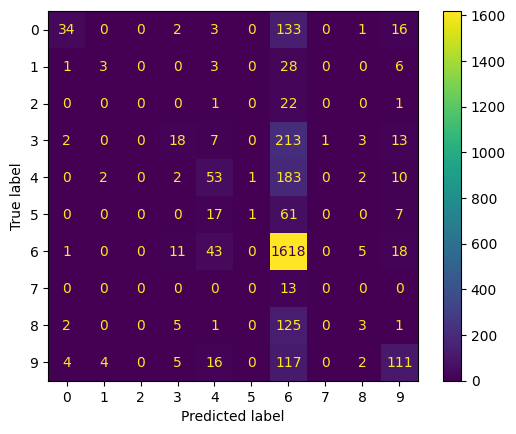

In [167]:
cm_display.plot()

## Más funciones auxiliares para los datos, no es relevante

In [ ]:
from pydub import AudioSegment

In [ ]:
path = './Data/Audios/'

for filename in tqdm(os.listdir(path)):
  if filename.endswith(".ogg"):
    ogg_path = os.path.join(path, filename)
    wav_path = os.path.join(path, os.path.splitext(filename)[0] + '.wav')

    try:
      audio = AudioSegment.from_file(ogg_path, format='ogg')
      audio.export(wav_path, format='wav')
    except Exception as e:
      print(f'Error convertig {ogg_path}: {e}')

In [ ]:
for filename in tqdm(os.listdir('./Data/Audios/')):
  file_path = os.path.join('./Data/Audios/', filename)
  # Checamos la terminacion
  if not ( filename.endswith('.wav') or filename.endswith('.ogg') ):
    try:
      os.remove(file_path)
      print(f'Se eliminó el archivo {filename}')
    except Exception as e:
      print(f'Error al eliminar el archivo {filename}')


In [ ]:
# recorre todos los archivos
for filename in tqdm(os.listdir('./Data/Audios/')):
    if filename.endswith(".ogg"):
        ogg_path = os.path.join('./Data/Audios/', filename)
        wav_path = os.path.join('./Data/Audios/', os.path.splitext(filename)[0] + ".wav")

        # Borra todos los .ogg que tengan su contraparte .wav
        if os.path.exists(wav_path):
            try:
                os.remove(ogg_path)
                print(f"Deleted duplicate .ogg file: {ogg_path}")
            except Exception as e:
                print(f"Error deleting {ogg_path}: {e}")